1. IMPORT LIBRARIES

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re



In [6]:
df = pd.read_csv("twitter_training2.csv", header=None)

df.columns = ["ID", "Topic", "Sentiment", "Text"]

print(df.head())

     ID        Topic  Sentiment  \
0    ID        TOPIC  SENTIMENT   
1  2401  Borderlands   Positive   
2  2401  Borderlands   Positive   
3  2401  Borderlands   Positive   
4  2401  Borderlands   Positive   

                                                Text  
0                                               TEXT  
1  im getting on borderlands and i will murder yo...  
2  I am coming to the borders and I will kill you...  
3  im getting on borderlands and i will kill you ...  
4  im coming on borderlands and i will murder you...  


In [7]:
print(df.isnull().sum())
df.dropna(inplace=True)

ID             0
Topic          0
Sentiment      0
Text         686
dtype: int64


In [9]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+|www\S+|https\S+", '', text)

    text = re.sub(r'@\w+', '', text)

    text = re.sub(r'#', '', text)

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    text = re.sub(r'\s+', ' ', text).strip()

    return text
df['Clean_Text'] = df['Text'].apply(clean_text)

print(df[['Text', 'Clean_Text']].head())

                                                Text  \
0                                               TEXT   
1  im getting on borderlands and i will murder yo...   
2  I am coming to the borders and I will kill you...   
3  im getting on borderlands and i will kill you ...   
4  im coming on borderlands and i will murder you...   

                                          Clean_Text  
0                                               text  
1  im getting on borderlands and i will murder yo...  
2  i am coming to the borders and i will kill you...  
3  im getting on borderlands and i will kill you all  
4  im coming on borderlands and i will murder you...  


In [13]:
def analyze_sentiment(text):

    score = sia.polarity_scores(text)

    compound = score['compound']

    if compound >= 0.05:
        return "Positive"

    elif compound <= -0.05:
        return "Negative"

    else:
        return "Neutral"


In [20]:
# Predict Sentiment
df['Predicted_Sentiment'] = df['Clean_Text'].apply(get_sentiment)

# Display Sample Output
print("\nSample Predictions:\n")
print(df[['Text', 'Predicted_Sentiment']].head())

# =============================
# SENTIMENT COUNT
# =============================

sentiment_counts = df['Predicted_Sentiment'].value_counts()

print("\nSentiment Counts:\n")
print(sentiment_counts)


Sample Predictions:

                                                Text Predicted_Sentiment
0                                               TEXT             Neutral
1  im getting on borderlands and i will murder yo...             Neutral
2  I am coming to the borders and I will kill you...             Neutral
3  im getting on borderlands and i will kill you ...             Neutral
4  im coming on borderlands and i will murder you...             Neutral

Sentiment Counts:

Predicted_Sentiment
Positive    33924
Negative    21214
Neutral     18859
Name: count, dtype: int64


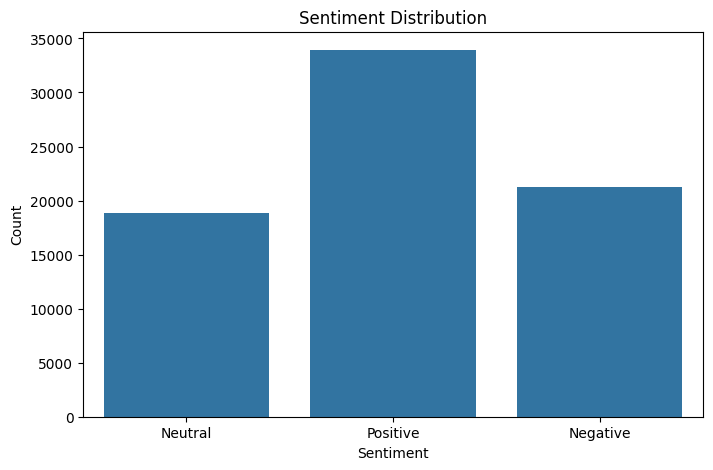

In [21]:
# BAR CHART
# =============================

plt.figure(figsize=(8,5))
sns.countplot(x='Predicted_Sentiment', data=df)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

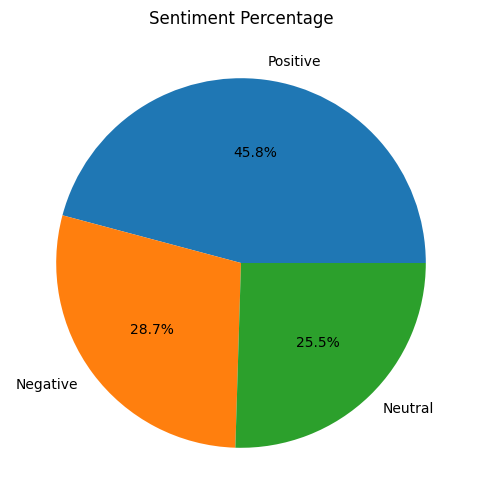

In [22]:
# PIE CHART
# =============================

plt.figure(figsize=(6,6))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%'
)

plt.title("Sentiment Percentage")

plt.show()

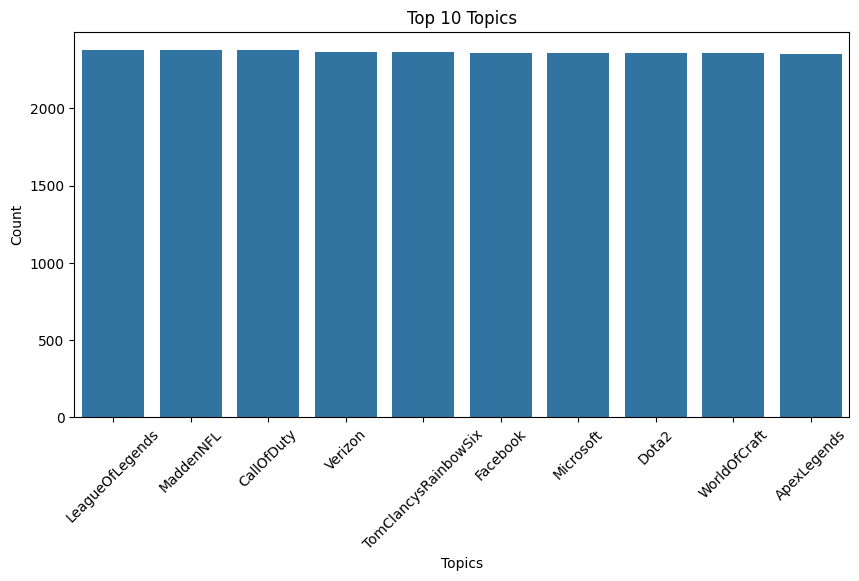

In [23]:
# TOPICS ANALYSIS
# =============================

top_topics = df['Topic'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_topics.index,
    y=top_topics.values
)

plt.title("Top 10 Topics")
plt.xlabel("Topics")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()